# Worm Length
In this notebook, we'll demonstrate how we can take a cutout of a worm and determine how long the worm is.

## Notebook Setup

In [1]:
# importing the necessary Python libraries
from __future__ import annotations

import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from skimage.morphology import skeletonize, remove_small_objects
from scipy.ndimage import binary_fill_holes

In [2]:
# Loading up the test image
image = cv2.imread('../data/processed_files/multiworm_feature_extraction/cutouts/5_t065_ch01/0.jpg', cv2.IMREAD_COLOR)

## Determining the Length of the Worm

### Performing the Image Conversion

In [10]:
# Converting the original image from BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Converting the original image to grayscale
grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Applying a slight gaussian blur to the grayscale image
blurred_grayscale_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)

# Enhancing local contrast so dim worm pixels are easier to recover
clahe = cv2.createCLAHE(clipLimit = 2.0, tileGridSize = (8, 8))
enhanced_grayscale_image = clahe.apply(blurred_grayscale_image)

# Applying a permissive Otsu threshold on the enhanced image
otsu_threshold, _ = cv2.threshold(
    enhanced_grayscale_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
_, otsu_binary_image = cv2.threshold(
    enhanced_grayscale_image, int(0.75 * otsu_threshold), 255, cv2.THRESH_BINARY
)

# Building a local adaptive mask to recover low-contrast sections
adaptive_binary_image = cv2.adaptiveThreshold(
    enhanced_grayscale_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    -3,
    )

# Combining global and local masks
combined_binary_image = cv2.bitwise_or(otsu_binary_image, adaptive_binary_image)

# Cleaning isolated noise then bridging small gaps
kernel = np.ones((3, 3), np.uint8)
combined_binary_image = cv2.morphologyEx(combined_binary_image, cv2.MORPH_OPEN, kernel, iterations = 1)
combined_binary_image = cv2.morphologyEx(combined_binary_image, cv2.MORPH_CLOSE, kernel, iterations = 2)

# Retrieving a boolean mask from the combined image
mask = combined_binary_image > 0

### Finding the Largest Component of the Worm

In [11]:
# Finding the largest group of touching non-zero pixels
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    mask.astype(np.uint8), connectivity = 8
)

# Setting the mask to be the largest label (if more than 1 is available)
if not num_labels <= 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = labels == largest_label

### Filling Holes & Removing Small Objects

In [12]:
# Filling holes in the mask
mask = binary_fill_holes(mask)

# Removing small objects
mask = remove_small_objects(mask, min_size = 30)

/var/folders/gz/mzdhdnzx0mg7p15jfr2y38k40000gn/T/ipykernel_19645/2979069353.py:5: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size = 30)


### Building the Skeleton Graph

In [13]:
# Skelotonizing the mask
skeleton = skeletonize(mask)

# Instantiating the graph
graph = nx.Graph()

# Getting the rows and the columns from the skeleton
rows, cols = np.nonzero(skeleton)

# Iterating over the rows and the columns
for row, col in zip(rows, cols):

    # Adding a node to the graph
    graph.add_node((row, col))

    # Iterating through all 8-connected neighboring offsets around each pixel
    for row_offset in (-1, 0, 1):
        for col_offset in (-1, 0, 1):
            # Skipping the center pixel offset (0, 0)
            if row_offset == 0 and col_offset == 0:
                continue

            # Computing the neighboring pixel coordinates
            neighbor_row = row + row_offset
            neighbor_col = col + col_offset

            # Checking whether the neighboring coordinates are within image bounds
            if 0 <= neighbor_row < skeleton.shape[0] and 0 <= neighbor_col < skeleton.shape[1]:

                # Adding an edge only when the neighboring pixel belongs to the skileton
                if skeleton[neighbor_row, neighbor_col]:

                    # Using sqrt(2) for diagonal moves and 1.0 for horizontal/vertical moves
                    edge_weight = math.sqrt(2) if abs(row_offset) + abs(col_offset) == 2 else 1.0

                    # Adding the edge to the graph
                    graph.add_edge((row, col), (neighbor_row, neighbor_col), weight = edge_weight)

### Finding the Longest Endpoint Path

In [14]:
# Determining the endpoint sof the graph
endpoints = [node for node, degree in graph.degree() if degree == 1]

In [15]:
# Instantiating variables to hold the best path and best length
best_path = None
best_length = -1.0

# Iterating over the endpoints
for i in range(len(endpoints)):
    for j in range(i + 1, len(endpoints)):

        # Getting the source and destination endpoints
        src = endpoints[i]
        dst = endpoints[j]

        try:
            path = nx.shortest_path(graph, src, dst, weight = 'weight')
            length = nx.shortest_path_length(graph, src, dst, weight = 'weight')
        except nx.NetworkXNoPath:
            continue

        if length > best_length:
            best_length = length
            best_path = path

path_rc = np.array(best_path)
path_y = path_rc[:, 0]
path_x = path_rc[:, 1]

### Plotting the Results

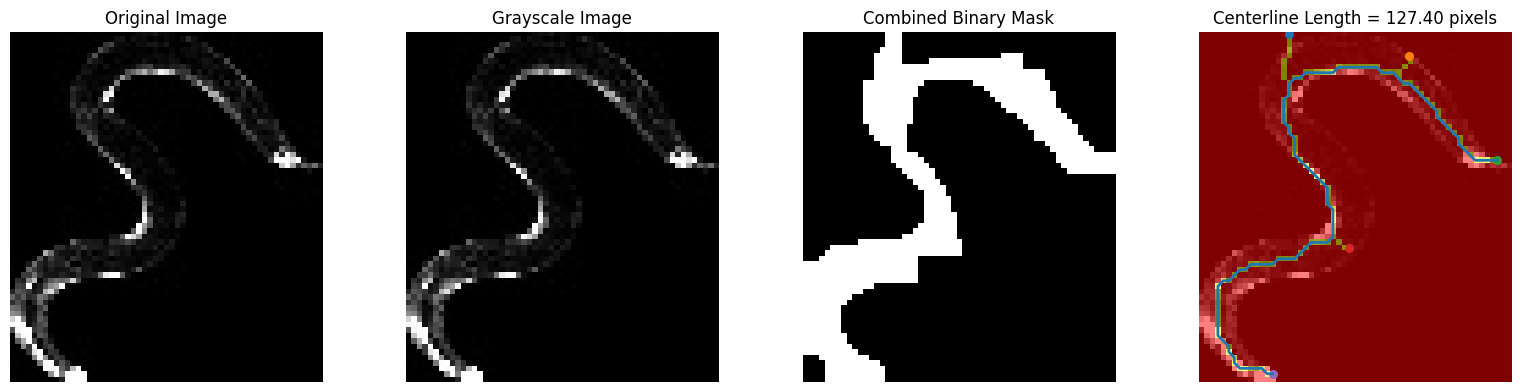

In [ ]:
# Instantiating the plots / subplots
fig, axes = plt.subplots(1, 4, figsize = (16, 4))

# Displaying the original image
axes[0].imshow(rgb_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Displaying the grayscale image
axes[1].imshow(grayscale_image, cmap = 'gray')
axes[1].set_title('Grayscale Image')
axes[1].axis('off')

# Displaying the combined binary mask
axes[2].imshow(mask, cmap = 'gray')
axes[2].set_title('Combined Binary Mask')
axes[2].axis('off')

# Displaying the longest path
axes[3].imshow(rgb_image)
axes[3].imshow(skeleton, cmap = 'autumn', alpha = 0.5)
axes[3].plot(path_x, path_y, linewidth = 2)
for r, c in endpoints:
    axes[3].scatter(c, r, s = 30)
axes[3].set_title(f'Centerline Length = {best_length:.2f} pixels')
axes[3].axis('off')

plt.tight_layout()
plt.show()